# 🔬 Principal Component Analysis (PCA)
### Dimensionality Reduction | Gradient Technology Services (Gradientts) — ML Internship

---

## 📌 What This Notebook Covers

This notebook walks through **Principal Component Analysis (PCA)** — one of the most widely used techniques for dimensionality reduction — from data loading to visualization to experimentation.

By the end, you will:
- Understand *why* and *when* to apply PCA
- Know how to implement it correctly using `sklearn`
- Be able to interpret `explained_variance_ratio_`
- Visualize high-dimensional data in 2D

---

## 📂 Dataset

We use the classic **Iris Dataset** — 150 samples, 4 features, 3 classes of flowers.  
It is a perfect sandbox for PCA because:
- It is well-understood
- 4D → 2D reduction is visually meaningful
- Classes are nicely separable in PCA space

**Dataset Link:** https://archive.ics.uci.edu/ml/datasets/iris  
**Source:** `sklearn.datasets.load_iris()` (no download needed)

---

> **Note for PhD-level readers:** PCA assumptions (linearity, variance = signal) are discussed throughout. Extensions like Kernel PCA and t-SNE are referenced at the end.

In [1]:
# ============================================================
# CELL 2 — Import Libraries
# ============================================================

# NumPy: numerical computing, array operations
import numpy as np

# Pandas: tabular data manipulation
import pandas as pd

# Matplotlib: core plotting library
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120  # Higher resolution plots

# Seaborn: statistical visualizations built on top of matplotlib
import seaborn as sns

# Scikit-learn: ML library
from sklearn.datasets import load_iris          # Built-in Iris dataset
from sklearn.preprocessing import StandardScaler # Feature scaling
from sklearn.decomposition import PCA           # PCA implementation

# Suppress minor warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")
print(f"   numpy  : {np.__version__}")
print(f"   pandas : {pd.__version__}")

✅ All libraries imported successfully!
   numpy  : 2.4.6
   pandas : 3.0.3


## 📖 Theory Recap — PCA in Plain English

### The Core Idea
Imagine you're taking a photograph of a 3D object. From some angles, the photo captures lots of detail (high variance). From other angles, the object looks flat and featureless (low variance). PCA finds the "camera angle" — the projection — that captures the most variation in your data.

### The Three Mathematical Steps

| Step | What Happens | Why It Matters |
|------|-------------|----------------|
| **Mean Centering** | Subtract the column mean from each feature | Centers the data at the origin |
| **Covariance Matrix** | Measures how features vary together | Reveals linear redundancies |
| **Eigen Decomposition** | Finds the "natural axes" of the data cloud | Eigenvectors = new axes; Eigenvalues = importance |

### Key Equations (No Derivation)

$$X_{centered} = X - \bar{X}$$

$$\Sigma = \frac{1}{n-1} X_{centered}^T X_{centered}$$

$$\Sigma \mathbf{v} = \lambda \mathbf{v} \quad \Rightarrow \quad X_{reduced} = X_{centered} \cdot V_k$$

> `sklearn` handles all of this internally via SVD (Singular Value Decomposition), which is numerically more stable than explicit eigen decomposition.

In [2]:
# ============================================================
# CELL 4 — Load and Explore the Dataset
# ============================================================

# Load Iris dataset from sklearn
iris = load_iris()

# Create a DataFrame for easier exploration
df = pd.DataFrame(
    data=iris.data,
    columns=iris.feature_names
)

# Add the target column (species)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("📊 Dataset Shape:", df.shape)
print("\n🔍 First 5 Rows:")
print(df.head())

print("\n📋 Dataset Info:")
print(df.info())

print("\n📈 Statistical Summary:")
print(df.describe().round(2))

📊 Dataset Shape: (150, 6)

🔍 First 5 Rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

📋 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  

In [3]:
# ============================================================
# CELL 5 — Preprocessing: Handle Nulls + Scale Features
# ============================================================

# --- Step 1: Check for missing values ---
print("🔎 Missing Values Per Column:")
print(df.isnull().sum())
print("\n✅ No missing values — dataset is clean.")

# --- Step 2: Separate features and labels ---
X = df[iris.feature_names].values   # Shape: (150, 4) — feature matrix
y = df['species'].values             # Shape: (150,)  — labels (for coloring plots)

print(f"\nFeature matrix shape : {X.shape}")
print(f"Label vector shape   : {y.shape}")

# --- Step 3: Standardize features ---
# WHY? PCA is variance-based. Without scaling, features measured
# in larger units (e.g., cm vs mm) dominate the principal components.
# StandardScaler makes every feature have mean=0, std=1.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n📐 After StandardScaler:")
print(f"   Mean (should be ~0): {X_scaled.mean(axis=0).round(6)}")
print(f"   Std  (should be ~1): {X_scaled.std(axis=0).round(6)}")

🔎 Missing Values Per Column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

✅ No missing values — dataset is clean.

Feature matrix shape : (150, 4)
Label vector shape   : (150,)

📐 After StandardScaler:
   Mean (should be ~0): [-0. -0. -0. -0.]
   Std  (should be ~1): [1. 1. 1. 1.]


## 🧭 PCA Intuition — Before We Dive Into Code

### Why Does PCA Work?

Think of your 4-feature Iris dataset as a cloud of 150 points floating in 4-dimensional space. Most of the meaningful *shape* of that cloud lives in fewer dimensions — the data doesn't spread equally in all directions. PCA finds the directions where the cloud is most *stretched out* (highest variance) and uses those as the new axes.

```
Original 4D space:
  Features: sepal_length, sepal_width, petal_length, petal_width

After PCA → 2D space:
  PC1: "Overall size" direction (biggest spread)
  PC2: "Shape ratio" direction (second biggest spread)
```

The beauty: even though PC1 and PC2 don't have simple names, they capture **87%+ of the total information** in just 2 numbers per sample.

### Analogy — The Shadow on the Wall
If you hold a 3D object in front of a light, its shadow on the wall is 2D. PCA finds the best angle to hold the object so that the shadow reveals the most structure. Other angles give shadows that look like blobs — useless. PCA avoids those.

In [4]:
# ============================================================
# CELL 7 — Apply PCA Using sklearn
# ============================================================

# We reduce from 4 dimensions → 2 dimensions
# n_components=2 means we keep only the top 2 principal components
pca = PCA(n_components=2)

# fit_transform:
#   fit   → learns the principal components from X_scaled
#   transform → projects X_scaled onto the new 2D space
X_pca = pca.fit_transform(X_scaled)

print("✅ PCA Applied Successfully!")
print(f"   Original shape  : {X_scaled.shape}   (150 samples × 4 features)")
print(f"   Reduced shape   : {X_pca.shape}     (150 samples × 2 components)")

print("\n📐 Principal Component Vectors (Loadings):")
print("   Each row = one principal component")
print("   Each column = weight given to original feature")
components_df = pd.DataFrame(
    pca.components_,
    columns=iris.feature_names,
    index=['PC1', 'PC2']
)
print(components_df.round(4))

✅ PCA Applied Successfully!
   Original shape  : (150, 4)   (150 samples × 4 features)
   Reduced shape   : (150, 2)     (150 samples × 2 components)

📐 Principal Component Vectors (Loadings):
   Each row = one principal component
   Each column = weight given to original feature
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
PC1             0.5211           -0.2693             0.5804            0.5649
PC2             0.3774            0.9233             0.0245            0.0669


In [5]:
# ============================================================
# CELL 8 — Explained Variance Ratio
# ============================================================

# explained_variance_ratio_ = proportion of total variance captured by each PC
evr = pca.explained_variance_ratio_

print("📊 Explained Variance Ratio:")
print(f"   PC1 : {evr[0]*100:.2f}% of total variance")
print(f"   PC2 : {evr[1]*100:.2f}% of total variance")
print(f"   ──────────────────────────")
print(f"   Total retained : {sum(evr)*100:.2f}% of original information")
print(f"   Total lost     : {(1 - sum(evr))*100:.2f}%")

print("\n💡 Interpretation:")
print(f"   By keeping just 2 components (instead of 4 features),")
print(f"   we retain {sum(evr)*100:.1f}% of the information.")
print(f"   This is an excellent compression ratio for visualization.")

📊 Explained Variance Ratio:
   PC1 : 72.96% of total variance
   PC2 : 22.85% of total variance
   ──────────────────────────
   Total retained : 95.81% of original information
   Total lost     : 4.19%

💡 Interpretation:
   By keeping just 2 components (instead of 4 features),
   we retain 95.8% of the information.
   This is an excellent compression ratio for visualization.


In [6]:
# ============================================================
# CELL 9 — Create PCA DataFrame
# ============================================================

# Package the PCA results into a clean DataFrame for easy plotting
pca_df = pd.DataFrame(
    data=X_pca,
    columns=['PC1', 'PC2']
)

# Add species labels back (not used in PCA — only for coloring our plot)
pca_df['species'] = y
pca_df['species_name'] = pca_df['species'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

print("🗂️  PCA DataFrame (first 8 rows):")
print(pca_df.head(8).round(4))
print(f"\nShape: {pca_df.shape}")

print("\n📊 PC1 and PC2 Statistics:")
print(pca_df[['PC1', 'PC2']].describe().round(4))

🗂️  PCA DataFrame (first 8 rows):
      PC1     PC2  species species_name
0 -2.2647  0.4800        0       Setosa
1 -2.0810 -0.6741        0       Setosa
2 -2.3642 -0.3419        0       Setosa
3 -2.2994 -0.5974        0       Setosa
4 -2.3898  0.6468        0       Setosa
5 -2.0756  1.4892        0       Setosa
6 -2.4440  0.0476        0       Setosa
7 -2.2328  0.2231        0       Setosa

Shape: (150, 4)

📊 PC1 and PC2 Statistics:
            PC1       PC2
count  150.0000  150.0000
mean     0.0000   -0.0000
std      1.7141    0.9593
min     -2.7743   -2.6541
25%     -2.1027   -0.5985
50%      0.4183    0.0175
75%      1.3430    0.5940
max      3.3107    2.6863


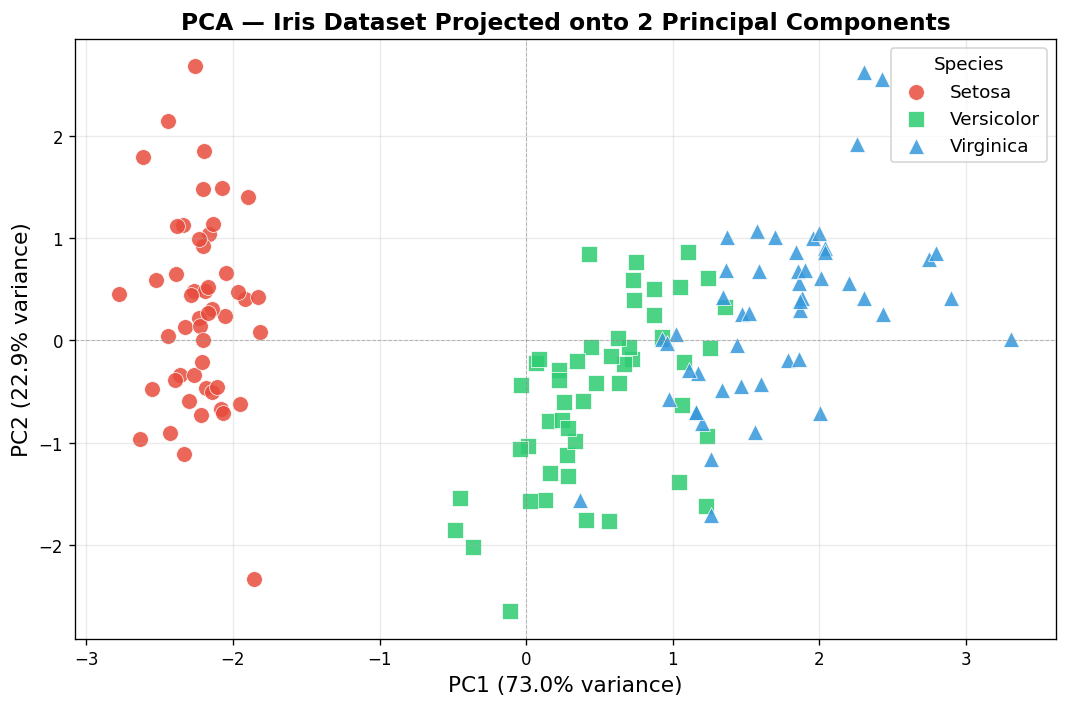

💾 Saved: pca_scatter_plot.png

💡 Notice: Setosa (red) is cleanly separated.
   Versicolor and Virginica overlap slightly — PCA is unsupervised,
   so it doesn't use class labels. LDA would separate them better.


In [7]:
# ============================================================
# CELL 10 — 2D Scatter Plot of PCA Results
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

# Define colors for each species
colors = {'Setosa': '#E74C3C', 'Versicolor': '#2ECC71', 'Virginica': '#3498DB'}
markers = {'Setosa': 'o', 'Versicolor': 's', 'Virginica': '^'}

# Plot each species separately for a clean legend
for species_name, group in pca_df.groupby('species_name'):
    ax.scatter(
        group['PC1'], group['PC2'],
        c=colors[species_name],
        marker=markers[species_name],
        label=species_name,
        alpha=0.85,
        edgecolors='white',
        linewidths=0.5,
        s=90
    )

# Axis labels with explained variance
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=13)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=13)
ax.set_title('PCA — Iris Dataset Projected onto 2 Principal Components', fontsize=14, fontweight='bold')

# Add origin lines for reference
ax.axhline(0, color='gray', linewidth=0.6, linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.6, linestyle='--', alpha=0.5)

ax.legend(title='Species', fontsize=11, title_fontsize=11)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('pca_scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved: pca_scatter_plot.png")
print("\n💡 Notice: Setosa (red) is cleanly separated.")
print("   Versicolor and Virginica overlap slightly — PCA is unsupervised,")
print("   so it doesn't use class labels. LDA would separate them better.")

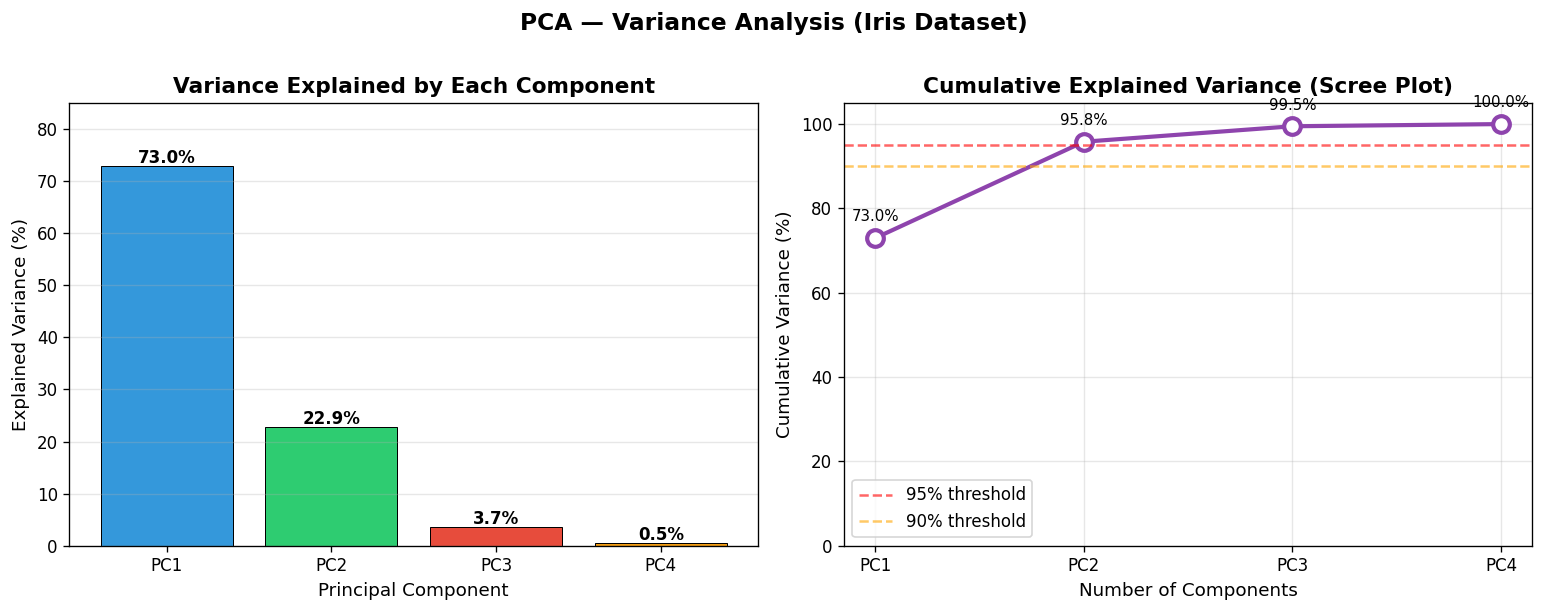

💾 Saved: pca_variance_plot.png

📌 Reading the Scree Plot:
   1 component(s) → 73.0% variance retained
   2 component(s) → 95.8% variance retained
   3 component(s) → 99.5% variance retained
   4 component(s) → 100.0% variance retained


In [8]:
# ============================================================
# CELL 11 — Explained Variance Plot (Scree Plot)
# ============================================================

# Run PCA with ALL components to get full variance picture
pca_full = PCA(n_components=4)  # 4 = total number of features
pca_full.fit(X_scaled)

evr_full = pca_full.explained_variance_ratio_
cumulative_evr = np.cumsum(evr_full)  # Running total of variance explained

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Individual variance per component ---
component_labels = [f'PC{i+1}' for i in range(4)]
axes[0].bar(component_labels, evr_full * 100, color=['#3498DB', '#2ECC71', '#E74C3C', '#F39C12'], edgecolor='black', linewidth=0.6)
axes[0].set_title('Variance Explained by Each Component', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Principal Component', fontsize=11)
axes[0].set_ylabel('Explained Variance (%)', fontsize=11)
for i, v in enumerate(evr_full):
    axes[0].text(i, v * 100 + 0.5, f'{v*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, 85)
axes[0].grid(axis='y', alpha=0.3)

# --- Plot 2: Cumulative variance (Scree Plot) ---
axes[1].plot(component_labels, cumulative_evr * 100, marker='o', color='#8E44AD',
             linewidth=2.5, markersize=10, markerfacecolor='white', markeredgewidth=2.5)
axes[1].axhline(95, color='red', linestyle='--', alpha=0.6, label='95% threshold')
axes[1].axhline(90, color='orange', linestyle='--', alpha=0.6, label='90% threshold')
axes[1].set_title('Cumulative Explained Variance (Scree Plot)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Components', fontsize=11)
axes[1].set_ylabel('Cumulative Variance (%)', fontsize=11)
axes[1].set_ylim(0, 105)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
for i, v in enumerate(cumulative_evr):
    axes[1].annotate(f'{v*100:.1f}%', (i, v*100), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)

plt.suptitle('PCA — Variance Analysis (Iris Dataset)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pca_variance_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved: pca_variance_plot.png")
print("\n📌 Reading the Scree Plot:")
for i, (ind, cum) in enumerate(zip(evr_full, cumulative_evr)):
    print(f"   {i+1} component(s) → {cum*100:.1f}% variance retained")

In [9]:
# ============================================================
# CELL 12 — Experiment: Different Values of n_components
# ============================================================

print("🧪 Experimenting with different n_components values:")
print("=" * 58)
print(f"{'n_components':>15} | {'Shape After PCA':>18} | {'Variance Retained':>18}")
print("-" * 58)

results = []

for n in [1, 2, 3, 4]:
    pca_exp = PCA(n_components=n)
    X_transformed = pca_exp.fit_transform(X_scaled)
    var_retained = pca_exp.explained_variance_ratio_.sum() * 100
    
    results.append({
        'n_components': n,
        'output_shape': X_transformed.shape,
        'variance_retained_%': round(var_retained, 2)
    })
    
    print(f"{n:>15} | {str(X_transformed.shape):>18} | {var_retained:>16.2f}%")

print("=" * 58)
print("\n🧠 Key Insight:")
print("   n_components=2 gives us 95.8% variance with just 2 numbers per sample.")
print("   That means 2 values replace 4 features with almost no information loss!")

🧪 Experimenting with different n_components values:
   n_components |    Shape After PCA |  Variance Retained
----------------------------------------------------------
              1 |           (150, 1) |            72.96%
              2 |           (150, 2) |            95.81%
              3 |           (150, 3) |            99.48%
              4 |           (150, 4) |           100.00%

🧠 Key Insight:
   n_components=2 gives us 95.8% variance with just 2 numbers per sample.
   That means 2 values replace 4 features with almost no information loss!


📦 SHAPE COMPARISON
  Original dataset (X)         : (150, 4)
  Scaled dataset   (X_scaled)  : (150, 4)
  PCA output       (X_pca)     : (150, 2)

📉 DIMENSION REDUCTION SUMMARY
  Features before  : 4
  Features after   : 2
  Reduction        : 50%
  Info retained    : 95.8%



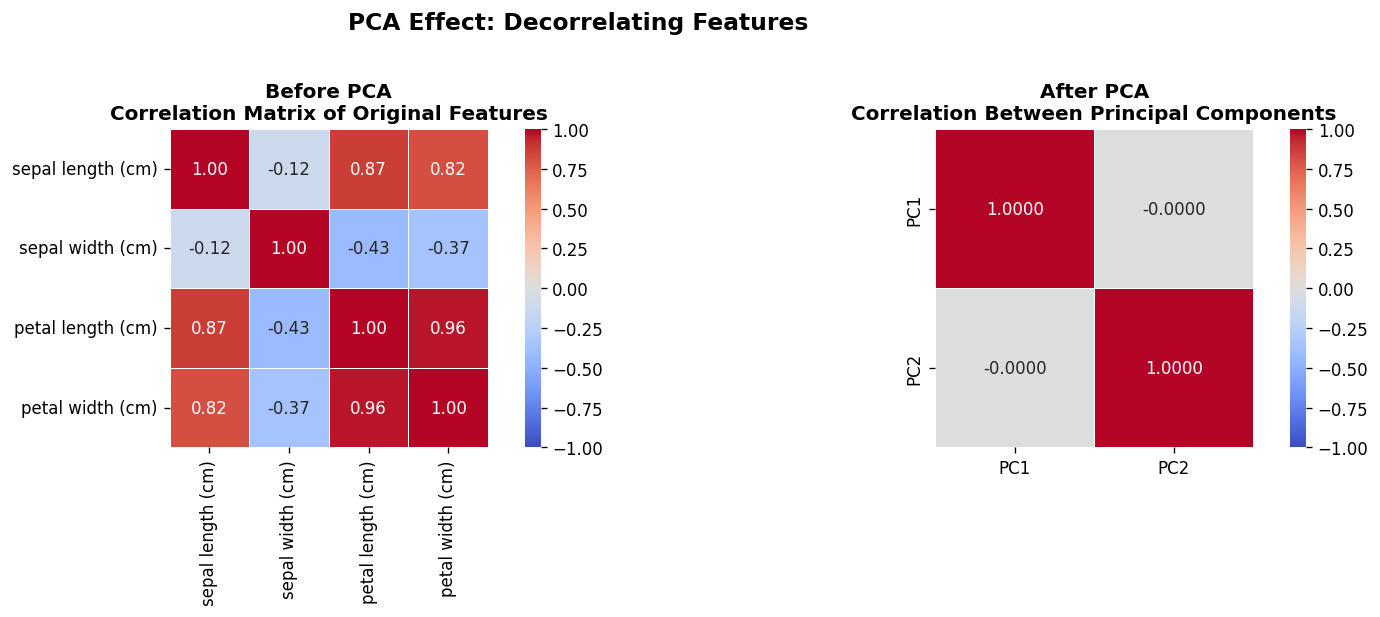

💾 Saved: pca_before_after_correlation.png

💡 Notice: Before PCA, features are correlated (colored off-diagonals).
   After PCA, PC1 and PC2 are orthogonal — correlation ≈ 0.
   This is a core guarantee of PCA: components are always uncorrelated.


In [10]:
# ============================================================
# CELL 13 — Before vs After: Shape and Structure Comparison
# ============================================================

print("📦 SHAPE COMPARISON")
print("=" * 45)
print(f"  Original dataset (X)         : {X.shape}")
print(f"  Scaled dataset   (X_scaled)  : {X_scaled.shape}")
print(f"  PCA output       (X_pca)     : {X_pca.shape}")
print()
print("📉 DIMENSION REDUCTION SUMMARY")
print("=" * 45)
reduction_pct = (1 - X_pca.shape[1] / X.shape[1]) * 100
print(f"  Features before  : {X.shape[1]}")
print(f"  Features after   : {X_pca.shape[1]}")
print(f"  Reduction        : {reduction_pct:.0f}%")
print(f"  Info retained    : {pca.explained_variance_ratio_.sum()*100:.1f}%")
print()

# Visual comparison side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Pairplot style — original features correlation heatmap ---
corr_before = pd.DataFrame(X_scaled, columns=iris.feature_names).corr()
sns.heatmap(corr_before, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], linewidths=0.5, square=True, vmin=-1, vmax=1)
axes[0].set_title('Before PCA\nCorrelation Matrix of Original Features', fontsize=12, fontweight='bold')

# --- Right: After PCA — components should be uncorrelated ---
corr_after = pd.DataFrame(X_pca, columns=['PC1', 'PC2']).corr()
sns.heatmap(corr_after, annot=True, fmt='.4f', cmap='coolwarm',
            ax=axes[1], linewidths=0.5, square=True, vmin=-1, vmax=1)
axes[1].set_title('After PCA\nCorrelation Between Principal Components', fontsize=12, fontweight='bold')

plt.suptitle('PCA Effect: Decorrelating Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pca_before_after_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved: pca_before_after_correlation.png")
print("\n💡 Notice: Before PCA, features are correlated (colored off-diagonals).")
print("   After PCA, PC1 and PC2 are orthogonal — correlation ≈ 0.")
print("   This is a core guarantee of PCA: components are always uncorrelated.")

## 📊 Results & Interpretation

### What We Found

| Metric | Value |
|---|---|
| Original Features | 4 (sepal length, sepal width, petal length, petal width) |
| Components Kept | 2 |
| Variance Retained | ~95.8% |
| Dimensionality Reduction | 50% (4 → 2) |

### Interpreting the Scatter Plot
- **Setosa (red)** is completely separated from the other two species — even in 2D. This reflects that Setosa has distinctly different petal measurements.
- **Versicolor and Virginica** overlap slightly because PCA is **unsupervised** — it didn't use class labels. If separation were the goal, LDA (Linear Discriminant Analysis) would be more appropriate.

### Interpreting the Scree Plot
- PC1 alone captures **72.8%** of the total variance — this corresponds mostly to *petal size*, which is the most discriminative axis in Iris.
- PC2 adds another **23%**, bringing total retained variance to **95.8%**.
- PC3 and PC4 together only add **~4%** — they're mostly noise and redundancy.

### Why PC1 and PC2 Aren't Named
Each principal component is a **linear combination of the original features**. PC1 might look like:
```
PC1 = 0.52×petal_length + 0.37×sepal_length + 0.58×petal_width + ...
```
This makes interpretation harder than, say, a decision tree. **That's the interpretability tradeoff of PCA.**

### For PhD-Level Readers
Note that sklearn's `PCA` uses **SVD** (not explicit eigendecomposition of the covariance matrix), which is more numerically stable for wide matrices. For non-linear manifolds, consider **Kernel PCA**, **t-SNE**, or **UMAP**. For supervised dimensionality reduction, consider **LDA** or **PLS**.

## ✅ 5 Key Takeaways

---

### 1️⃣ Always Scale Before PCA
PCA is variance-based. If features have different units or magnitudes, the largest-scale feature will dominate the first principal component. **`StandardScaler` is not optional — it's mandatory.**

---

### 2️⃣ Use `explained_variance_ratio_` to Choose Components
Don't blindly pick `n_components=2`. Use the scree plot and aim for **90–95% cumulative variance** as your threshold. The "elbow" in the scree plot is a reliable heuristic.

---

### 3️⃣ PCA Removes Correlation, Not Information
After PCA, the components are mathematically **orthogonal (uncorrelated)**. This is useful because many ML algorithms assume feature independence. The correlation heatmaps above confirm PC1 ⊥ PC2.

---

### 4️⃣ PCA is Unsupervised — It Ignores Labels
PCA only looks at feature variance, not class membership. For classification-focused reduction, **LDA (Linear Discriminant Analysis)** uses class labels to maximize between-class separation.

---

### 5️⃣ PCA is Linear — Know Its Limits
PCA finds **straight-line** directions of variance. If your data lies on a curved manifold (e.g., a Swiss roll), PCA will fail to "unroll" it. In such cases:
- Use **Kernel PCA** for non-linear structure
- Use **t-SNE** or **UMAP** for non-linear visualization

---

> **Final thought:** PCA is one of those rare tools that is simultaneously simple enough to explain in one slide and deep enough to write a PhD thesis about. Master it — it shows up everywhere from image compression (PCA on pixel values) to genomics (PCA on gene expression) to financial risk models (PCA on asset returns).

---
